# 2. Deploy Strands Decider 2B on Amazon SageMaker AI, then test and benchmark it on two GPUs

> **Note:** This is sample code for demonstration purposes only and is not intended for production use without
> additional security testing and review.

[Strands Decider 2B](https://huggingface.co/StrandsAgents/strands-decider-2B-hobson-v19) answers typed questions about a
piece of text (the "state") with calibrated probabilities: `noul` (yes/no), `choice` (one of N options) and `score`
(a level on an ordered scale). Agents use it for routing, tool selection, argument checks and guardrails, where a full
LLM call is slow and expensive. It is Qwen3.5-2B-Base with a LoRA adapter and a small pointer head, served by the
authors' own engine ([strands-labs/strands-decider](https://github.com/strands-labs/strands-decider)), not by vLLM.

The sample serves that engine from a small image built on the AWS PyTorch Deep Learning Container:

```
InvokeEndpoint ──► /invocations  (container/serve.py front → app.py workers)
                       │
                       ▼
                   strands-decider engine: Qwen3.5-2B torso + LoRA + pointer head   (GPU, 1-3 worker processes)
```

**Two endpoints, two price points.** The model is small enough for the cheapest SageMaker GPU, the NVIDIA T4 in
`ml.g4dn`, but the T4 has no bf16, so it runs the model in fp32 (exact, about 7 GiB). The second endpoint uses the
cheapest 24-48 GB GPU that has capacity, in bf16, with three model copies sharing the GPU. Both use instance pools, so a
capacity shortage falls back to the next type instead of failing:

| Endpoint | Pools (priority order) | Precision | Workers | $/h |
|---|---|---|---|---|
| `t4` | `ml.g4dn.xlarge`, `ml.g4dn.2xlarge` | fp32 | 1 | 0.736 / 0.94 |
| `gpu` | `ml.g6.xlarge`, `ml.g6.2xlarge`, `ml.g5.xlarge`, `ml.g5.2xlarge`, `ml.g6e.xlarge` | bf16 | 3 | 1.127 / 1.222 / 1.408 / 1.515 / 2.605 |

`ml.g7` and `ml.g7e` are not in the list: they cost more than all of these, and new accounts have a quota of 0 for them.

**Prerequisites:** Docker on the machine running this notebook (to build the image), and the AWS permissions listed in
the README. **Run time:** about 50 minutes (plus about 20 minutes for the first image build). **Cost:** $1.86 to
$3.55 per hour while both endpoints run, depending on which pools have capacity, plus ECR and S3 storage. The
clean-up cell at the end is commented out by default: uncomment and run it when you are done.

## 1. Configuration
The decider and base-model revisions, the container base image and the Python packages in
`container/requirements.txt` are pinned. The image build also applies Ubuntu's current security updates, so two
builds on different days can differ in OS package versions; the image tag records the inputs, not that date.

In [1]:
import json, math, time, hashlib, base64, concurrent.futures as cf
from pathlib import Path
import boto3, docker, numpy as np, pandas as pd
from botocore.config import Config
from botocore.exceptions import ClientError

REGION = "us-east-1"
DECIDER_ID, DECIDER_REV = "StrandsAgents/strands-decider-2B-hobson-v19", "bb282d786bc251fd4e3068de3ada9ddbb38127cd"
BASE_ID, BASE_REV = "Qwen/Qwen3.5-2B-Base", "b1485b2fa6dfa1287294f269f5fb618e03d52d7c"   # from the decider's provenance.json
BASE_IMAGE = f"763104351884.dkr.ecr.{REGION}.amazonaws.com/pytorch-training:2.9.0-gpu-py312-cu130-ubuntu22.04-sagemaker-v2.2"
INFERENCE_AMI = "al2023-ami-sagemaker-inference-gpu-4-1"      # NVIDIA 580 driver, needed by CUDA 13 images
PRICE_PER_HOUR = {"ml.g4dn.xlarge": 0.736, "ml.g4dn.2xlarge": 0.94, "ml.g6.xlarge": 1.1267,
                  "ml.g6.2xlarge": 1.222, "ml.g5.xlarge": 1.408, "ml.g5.2xlarge": 1.515, "ml.g6e.xlarge": 2.6054}   # SageMaker on-demand, USD (us-east-1 and us-west-2)
ENDPOINTS = {
    "t4":  {"pools": ["ml.g4dn.xlarge", "ml.g4dn.2xlarge"], "env": {"DECIDER_WORKERS": "1"}},
    "gpu": {"pools": ["ml.g6.xlarge", "ml.g6.2xlarge", "ml.g5.xlarge", "ml.g5.2xlarge", "ml.g6e.xlarge"], "env": {"DECIDER_WORKERS": "3"}},
}
NAME = "strands-decider"                 # endpoints -t4 and -gpu; one deployment per account and Region, since
                                         # the image, artifact and role are shared
REPO = "strands-decider-sagemaker"       # private ECR repository for the serving image
ROLE_NAME = "strands-decider-sagemaker-execution"
EXISTING_ROLE_ARN = None   # set to an existing SageMaker execution role ARN to use it instead of creating one
ROLE_TAG = {"Key": "created-by", "Value": "strands-decider-sagemaker-sample"}   # also on the models, configs and endpoints

session = boto3.Session(region_name=REGION)
account = session.client("sts").get_caller_identity()["Account"]
BUCKET = f"sagemaker-{REGION}-{account}"
sm, ecr = session.client("sagemaker"), session.client("ecr")
s3 = session.client("s3", config=Config(max_pool_connections=32))   # parallel multipart transfers
smr = session.client("sagemaker-runtime", config=Config(max_pool_connections=128, read_timeout=70,
                                                        retries={"max_attempts": 1, "mode": "standard"}))

def show(x):
    """Printable form of a value with the account ID masked, so saved outputs do not leak it."""
    return str(x).replace(account, "<account-id>")

print(f"region {REGION}  bucket {show(BUCKET)}\nendpoints {json.dumps({k: v['pools'] for k, v in ENDPOINTS.items()})}")

region us-east-1  bucket sagemaker-us-east-1-<account-id>
endpoints {"t4": ["ml.g4dn.xlarge", "ml.g4dn.2xlarge"], "gpu": ["ml.g6.xlarge", "ml.g6.2xlarge", "ml.g5.xlarge", "ml.g5.2xlarge", "ml.g6e.xlarge"]}


## 2. Execution role (least privilege)
The endpoints only need to read their artifact prefix (in this account's bucket only), pull the serving image, and
write logs and metrics. Skipped if you set `EXISTING_ROLE_ARN`.

In [2]:
iam = session.client("iam")
# Decided from the configuration each time, so re-running this cell (say after the clean-up) creates the role again.
OURS = EXISTING_ROLE_ARN is None
ROLE_ARN = EXISTING_ROLE_ARN
if OURS:
    # aws:SourceAccount stops other accounts' SageMaker resources from using this role (confused deputy).
    trust = {"Version": "2012-10-17", "Statement": [{"Effect": "Allow", "Action": "sts:AssumeRole",
             "Principal": {"Service": "sagemaker.amazonaws.com"},
             "Condition": {"StringEquals": {"aws:SourceAccount": account}}}]}
    policy = {"Version": "2012-10-17", "Statement": [
        {"Effect": "Allow", "Action": "s3:GetObject", "Resource": f"arn:aws:s3:::{BUCKET}/strands-decider/*",
         "Condition": {"StringEquals": {"s3:ResourceAccount": account}}},
        {"Effect": "Allow", "Action": "s3:ListBucket", "Resource": f"arn:aws:s3:::{BUCKET}",
         "Condition": {"StringLike": {"s3:prefix": ["strands-decider/*"]},
                       "StringEquals": {"s3:ResourceAccount": account}}},
        {"Effect": "Allow", "Action": "ecr:GetAuthorizationToken", "Resource": "*"},
        {"Effect": "Allow", "Action": ["ecr:BatchGetImage", "ecr:GetDownloadUrlForLayer",
                                       "ecr:BatchCheckLayerAvailability"],
         "Resource": f"arn:aws:ecr:{REGION}:{account}:repository/{REPO}"},
        {"Effect": "Allow", "Action": ["logs:CreateLogGroup", "logs:CreateLogStream", "logs:PutLogEvents",
                                       "logs:DescribeLogStreams"],
         "Resource": f"arn:aws:logs:{REGION}:{account}:log-group:/aws/sagemaker/*"},
        {"Effect": "Allow", "Action": "cloudwatch:PutMetricData", "Resource": "*",
         "Condition": {"StringLike": {"cloudwatch:namespace": ["/aws/sagemaker/*", "AWS/SageMaker*"]}}}]}
    # The role is tagged when created, so a re-run updates only a role this notebook made (and clean-up deletes only
    # that one). An existing role without the tag belongs to someone else: the cell stops instead of changing it.
    try:
        ROLE_ARN = iam.create_role(RoleName=ROLE_NAME, AssumeRolePolicyDocument=json.dumps(trust),
                                   Description="Strands Decider SageMaker endpoints", Tags=[ROLE_TAG])["Role"]["Arn"]
    except iam.exceptions.EntityAlreadyExistsException:
        if ROLE_TAG not in iam.list_role_tags(RoleName=ROLE_NAME)["Tags"]:
            raise SystemExit(f"a role named {ROLE_NAME} already exists and was not created by this notebook: "
                             "set EXISTING_ROLE_ARN to use it as it is, or change ROLE_NAME")
        ROLE_ARN = iam.get_role(RoleName=ROLE_NAME)["Role"]["Arn"]
        iam.update_assume_role_policy(RoleName=ROLE_NAME, PolicyDocument=json.dumps(trust))
    iam.put_role_policy(RoleName=ROLE_NAME, PolicyName="strands-decider-endpoint", PolicyDocument=json.dumps(policy))
    time.sleep(15)   # IAM is eventually consistent: let the role and its policy propagate before SageMaker uses them
print("execution role:", show(ROLE_ARN))

execution role: arn:aws:iam::<account-id>:role/strands-decider-sagemaker-execution


## 3. Build and push the serving image
`container/` holds the Dockerfile, `app.py` (the SageMaker `/ping` and `/invocations` contract around the decider
engine), `serve.py` (starts the worker processes) and the pinned Python packages. The image tag is a hash of that directory, so an unchanged image is never
rebuilt and a changed one never overwrites a tag in use (the repository has immutable tags and scans each push).
The first build pulls the 18 GB PyTorch base image.

In [3]:
ctx = Path("container")
digest = hashlib.sha256()
# Exactly what the build uses: the Dockerfile and the files it copies (requirements.txt, serve.py, app.py).
for name in ("Dockerfile", "requirements.txt", "serve.py", "app.py"):
    digest.update(name.encode() + b"\0" + (ctx / name).read_bytes())
digest.update(BASE_IMAGE.encode())
TAG = digest.hexdigest()[:12]

# Like the role, the repository is tagged when created; an existing one without the tag (or with mutable tags) is
# someone else's, so the cell stops rather than pushing into it, and the clean-up never deletes it.
REPO_TAG = {"Key": "created-by", "Value": "strands-decider-sagemaker-sample"}
try:
    ecr.create_repository(repositoryName=REPO, imageTagMutability="IMMUTABLE",
                          imageScanningConfiguration={"scanOnPush": True},
                          encryptionConfiguration={"encryptionType": "AES256"}, tags=[REPO_TAG])
except ecr.exceptions.RepositoryAlreadyExistsException:
    repo = ecr.describe_repositories(repositoryNames=[REPO])["repositories"][0]
    if (REPO_TAG not in ecr.list_tags_for_resource(resourceArn=repo["repositoryArn"])["tags"]
            or repo["imageTagMutability"] != "IMMUTABLE"):
        raise SystemExit(f"an ECR repository named {REPO} already exists and was not created by this notebook: "
                         "change REPO")
IMAGE = f"{account}.dkr.ecr.{REGION}.amazonaws.com/{REPO}:{TAG}"
try:
    ecr.describe_images(repositoryName=REPO, imageIds=[{"imageTag": TAG}])
    print("image already in ECR:", show(IMAGE))
except ecr.exceptions.ImageNotFoundException:
    client = docker.from_env()
    for registry in ("763104351884", account):        # the AWS DLC registry (base image) and our own
        token = ecr.get_authorization_token(registryIds=[registry])["authorizationData"][0]
        user, password = base64.b64decode(token["authorizationToken"]).decode().split(":", 1)
        client.login(username=user, password=password, registry=token["proxyEndpoint"], reauth=True)
    t0 = time.time()
    # linux/amd64 explicitly: SageMaker GPU instances are x86, whatever machine builds the image.
    client.images.build(path=str(ctx), tag=IMAGE, buildargs={"BASE_IMAGE": BASE_IMAGE}, rm=True, pull=True,
                        platform="linux/amd64")
    for line in client.images.push(IMAGE, stream=True, decode=True):
        if "error" in line:
            raise RuntimeError(line["error"])
    print(f"built and pushed {show(IMAGE)} in {(time.time() - t0) / 60:.0f} min")

# ECR's scan of the pushed image (it starts a few seconds after the push): report findings by severity. With
# Amazon Inspector enhanced scanning the status settles on ACTIVE instead of COMPLETE.
scan = {"imageScanStatus": {"status": "NOT_STARTED"}}
for _ in range(90):
    try:
        scan = ecr.describe_image_scan_findings(repositoryName=REPO, imageId={"imageTag": TAG})
        if scan["imageScanStatus"]["status"] in ("COMPLETE", "ACTIVE", "FAILED", "UNSUPPORTED_IMAGE",
                                                 "FINDINGS_UNAVAILABLE", "SCAN_ELIGIBILITY_EXPIRED"):
            break
    except ecr.exceptions.ScanNotFoundException:
        pass
    time.sleep(10)
print("ECR image scan:", scan["imageScanStatus"]["status"],
      scan.get("imageScanFindings", {}).get("findingSeverityCounts", {}))

image already in ECR: <account-id>.dkr.ecr.us-east-1.amazonaws.com/strands-decider-sagemaker:14048f3729cc


ECR image scan: COMPLETE {}


## 4. Build the model artifact in S3
One **uncompressed** S3 prefix, mounted read-only at `/opt/ml/model`. The decider repository goes in as-is, and the
base model goes in as an offline Hugging Face cache pinned to `BASE_REV`, which is how the decider's loader finds it.
Because nothing is downloaded at start-up, the endpoints run with **network isolation**.

```
/opt/ml/model/
├── decider/                                   StrandsAgents/strands-decider-2B-hobson-v19 (adapter, head, tokenizer)
└── hf/hub/models--Qwen--Qwen3.5-2B-Base/
    ├── refs/main                              -> BASE_REV
    └── snapshots/BASE_REV/                    config + 4.3 GB of bf16 weights
```

In [4]:
from fnmatch import fnmatch
from huggingface_hub import HfApi, snapshot_download
from boto3.s3.transfer import TransferConfig

OWNER = {"ExpectedBucketOwner": account}   # every S3 call fails if the bucket belongs to someone else
# The SageMaker default bucket name is predictable, so check that this account owns it, and create it if missing.
try:
    s3.head_bucket(Bucket=BUCKET, **OWNER)
except ClientError as e:
    if e.response["Error"]["Code"] not in ("404", "NoSuchBucket"):
        raise SystemExit(f"{show(BUCKET)} exists but is not usable by this account ({e.response['Error']['Code']})")
    s3.create_bucket(Bucket=BUCKET, **({} if REGION == "us-east-1" else
                                       {"CreateBucketConfiguration": {"LocationConstraint": REGION}}))
    s3.put_public_access_block(Bucket=BUCKET, PublicAccessBlockConfiguration={
        "BlockPublicAcls": True, "IgnorePublicAcls": True, "BlockPublicPolicy": True, "RestrictPublicBuckets": True})
    print("created", show(BUCKET))

# A bucket encrypted with a customer KMS key also needs kms:Decrypt for the endpoints to read the artifact.
rules = []
try:
    rules = s3.get_bucket_encryption(Bucket=BUCKET, **OWNER)["ServerSideEncryptionConfiguration"]["Rules"]
except ClientError as e:
    if e.response["Error"]["Code"] != "ServerSideEncryptionConfigurationNotFoundError":
        raise
# S3 accepts a key ID, alias or ARN here; IAM needs the key ARN, so resolve it.
kms_keys = [session.client("kms").describe_key(KeyId=r["ApplyServerSideEncryptionByDefault"]["KMSMasterKeyID"])
            ["KeyMetadata"]["Arn"] for r in rules
            if r.get("ApplyServerSideEncryptionByDefault", {}).get("KMSMasterKeyID")]
if kms_keys and OURS:
    iam.put_role_policy(RoleName=ROLE_NAME, PolicyName="strands-decider-kms", PolicyDocument=json.dumps({
        "Version": "2012-10-17", "Statement": [{"Effect": "Allow", "Action": "kms:Decrypt", "Resource": kms_keys,
        "Condition": {"StringEquals": {"kms:ViaService": f"s3.{REGION}.amazonaws.com"}}}]}))
    time.sleep(10)
if kms_keys and not OURS:
    print("bucket uses SSE-KMS: make sure your EXISTING_ROLE_ARN may kms:Decrypt with", show(kms_keys))
else:
    algos = sorted({r.get("ApplyServerSideEncryptionByDefault", {}).get("SSEAlgorithm", "AES256") for r in rules})
    print("bucket encryption:", ", ".join(algos) or "AES256",
          "(kms:Decrypt granted to the role)" if kms_keys else "(no customer managed key)")

BUILD = Path("build")
PREFIX = f"strands-decider/{DECIDER_REV[:8]}-{BASE_REV[:8]}/"   # model inputs only; code is in the image
base_root = f"hf/hub/models--{BASE_ID.replace('/', '--')}"
BASE_PATTERNS = ["*.json", "*.safetensors"]
have = {o["Key"][len(PREFIX):]: o["Size"] for p in s3.get_paginator("list_objects_v2").paginate(
        Bucket=BUCKET, Prefix=PREFIX, **OWNER) for o in p.get("Contents", [])}

# Every file the artifact needs, with its size from the Hub, so a complete prefix is not downloaded again.
hub = HfApi()
need = {f"decider/{f.rfilename}": f.size
        for f in hub.model_info(DECIDER_ID, revision=DECIDER_REV, files_metadata=True).siblings}
need.update({f"{base_root}/snapshots/{BASE_REV}/{f.rfilename}": f.size
             for f in hub.model_info(BASE_ID, revision=BASE_REV, files_metadata=True).siblings
             if any(fnmatch(f.rfilename, p) for p in BASE_PATTERNS)})
need[f"{base_root}/refs/main"] = len(BASE_REV)

t0, sent = time.time(), 0
if all(have.get(k) == n for k, n in need.items()):
    print("S3 already holds every file of this revision; nothing to download")
else:
    decider_dir = Path(snapshot_download(DECIDER_ID, revision=DECIDER_REV, local_dir=BUILD / "decider"))
    base_snapshot = Path(snapshot_download(BASE_ID, revision=BASE_REV, cache_dir=BUILD / "hf" / "hub",
                                           allow_patterns=BASE_PATTERNS))
    # Map each file to its key under the artifact; the cache's blobs/ are skipped (snapshots/ already resolve to them).
    files = {f"decider/{f.relative_to(decider_dir).as_posix()}": f for f in decider_dir.rglob("*")
             if f.is_file() and ".cache" not in f.relative_to(decider_dir).parts}
    files.update({f"{base_root}/snapshots/{BASE_REV}/{f.relative_to(base_snapshot).as_posix()}": f
                  for f in base_snapshot.rglob("*") if f.is_file()})
    (BUILD / "refs-main").write_text(BASE_REV)
    files[f"{base_root}/refs/main"] = BUILD / "refs-main"
    if not set(need) <= set(files):
        raise RuntimeError(f"missing from the download: {sorted(set(need) - set(files))}")
    cfg = TransferConfig(multipart_chunksize=64 * 2**20, max_concurrency=16)
    for key in need:                     # only this revision's files, even if the build directory holds older ones
        f = files[key]
        if have.get(key) != f.stat().st_size:
            s3.upload_file(str(f), BUCKET, PREFIX + key, Config=cfg, ExtraArgs=OWNER)
            sent += 1
print(f"artifact {show(f's3://{BUCKET}/{PREFIX}')}: {len(need)} files, "
      f"{sum(need.values()) / 1e9:.2f} GB ({sent} uploaded in this run, {time.time() - t0:.0f} s)")

bucket encryption: AES256 (no customer managed key)


S3 already holds every file of this revision; nothing to download
artifact s3://sagemaker-us-east-1-<account-id>/strands-decider/bb282d78-b1485b2f/: 46 files, 4.66 GB (0 uploaded in this run, 0 s)


## 5. Deploy both endpoints

| Setting | Value | Why |
|---|---|---|
| `DECIDER_WORKERS` | 1 on T4, 3 on 24-48 GB GPUs | the engine answers one request at a time; three copies behind a small front that sends each request to the least busy one let requests overlap on the GPU (ticket throughput rises about 1.7x from 1 to 4 concurrent requests in section 8, then levels off), while a second copy on the T4 added nothing |
| precision | automatic | bf16 where the GPU has it natively, fp32 on the T4 (fp16 can overflow in this architecture) |
| kernel warm-up | in the container | compiles the Triton kernels before `/ping` turns healthy; otherwise the first request takes 35-100 s |
| network isolation | on | everything the container needs is in the image and the artifact |
| `InstancePools` | 2 types (T4), 5 types (GPU) | GPU capacity is often short; SageMaker falls back instead of failing (pools need at least 2 entries) |
| start-up timeouts | 1200 s | image pull plus kernel compile take longer than the 8-minute default |

In [5]:
def describe(call, **kw):
    """The resource's description, or None when it does not exist."""
    try:
        return call(**kw)
    except ClientError as e:
        if e.response["Error"]["Code"] == "ValidationException":     # SageMaker's "could not find"
            return None
        raise

names = {k: f"{NAME}-{k}" for k in ENDPOINTS}
# One read of each resource. Re-running this cell resumes endpoints that are Creating, InService or Updating
# (after a kernel restart, when the wait below ran out, or while autoscaling acts), provided they were deployed
# with this run's image, artifact, environment, pools and AMI. It removes what a failed deploy left behind, if
# this notebook created it (tagged); a live endpoint with another configuration needs the clean-up section first.
resume = {}
for k, n in names.items():
    ep = describe(sm.describe_endpoint, EndpointName=n)
    # The config and model the endpoint runs now (an update may have moved it to others), else this cell's names.
    cfg = describe(sm.describe_endpoint_config, EndpointConfigName=ep["EndpointConfigName"] if ep else n)
    model_name = ((cfg or {}).get("ProductionVariants") or [{}])[0].get("ModelName", n) if ep else n
    live = {"endpoint": ep, "endpoint config": cfg, "model": describe(sm.describe_model, ModelName=model_name)}
    resume[k] = bool(live["endpoint"]) and live["endpoint"]["EndpointStatus"] in ("Creating", "InService", "Updating")
    if resume[k]:
        c = (live["model"] or {}).get("PrimaryContainer", {})
        v = ((live["endpoint config"] or {}).get("ProductionVariants") or [{}])[0]
        pools = [p["InstanceType"] for p in sorted(v.get("InstancePools", []), key=lambda p: p["Priority"])]
        if (c.get("ModelDataSource", {}).get("S3DataSource", {}).get("S3Uri"), c.get("Image"), c.get("Environment", {}),
                pools, v.get("InferenceAmiVersion")) != (f"s3://{BUCKET}/{PREFIX}", IMAGE, ENDPOINTS[k]["env"],
                                                         ENDPOINTS[k]["pools"], INFERENCE_AMI):
            raise SystemExit(f"{n} is live with a different configuration than this run: "
                             "run the clean-up section, then deploy again")
    elif live["endpoint"] and live["endpoint"]["EndpointStatus"] not in ("Failed", "OutOfService", "UpdateRollbackFailed"):
        raise SystemExit(f"{n} is {live['endpoint']['EndpointStatus']}: wait for it to settle, or run the clean-up section")
    elif any(live.values()):
        # What a failed deploy of this endpoint left behind; the image, artifact and role stay.
        arns = {x: d.get("EndpointArn") or d.get("EndpointConfigArn") or d.get("ModelArn") for x, d in live.items() if d}
        foreign = [x for x, arn in arns.items() if ROLE_TAG not in sm.list_tags(ResourceArn=arn)["Tags"]]
        if foreign:
            raise SystemExit(f"{n}: the {', '.join(foreign)} of that name was not created by this notebook; "
                             "remove it yourself or change NAME")
        print(f"{n}: removing the {', '.join(arns)} left by an earlier failed deploy")
        if live["endpoint"]:
            sm.delete_endpoint(EndpointName=n)
            sm.get_waiter("endpoint_deleted").wait(EndpointName=n)
        if live["endpoint config"]:
            sm.delete_endpoint_config(EndpointConfigName=live["endpoint config"]["EndpointConfigName"])
        if live["model"]:
            sm.delete_model(ModelName=live["model"]["ModelName"])

for key, spec in ENDPOINTS.items():
    n = names[key]
    if resume[key]:
        continue
    sm.create_model(ModelName=n, ExecutionRoleArn=ROLE_ARN, EnableNetworkIsolation=True, Tags=[ROLE_TAG], PrimaryContainer={
        "Image": IMAGE, "Environment": spec["env"],
        "ModelDataSource": {"S3DataSource": {"S3Uri": f"s3://{BUCKET}/{PREFIX}", "S3DataType": "S3Prefix",
                                             "CompressionType": "None"}}})
    sm.create_endpoint_config(EndpointConfigName=n, Tags=[ROLE_TAG], ProductionVariants=[{
        "VariantName": "AllTraffic", "ModelName": n, "InitialInstanceCount": 1,
        "InstancePools": [{"InstanceType": t, "Priority": i + 1} for i, t in enumerate(spec["pools"])],
        "VariantInstanceProvisionTimeoutInSeconds": 600,      # per pool, before trying the next one
        "RoutingConfig": {"RoutingStrategy": "LEAST_OUTSTANDING_REQUESTS"},
        "InferenceAmiVersion": INFERENCE_AMI,
        "ContainerStartupHealthCheckTimeoutInSeconds": 1200, "ModelDataDownloadTimeoutInSeconds": 1200}])
    sm.create_endpoint(EndpointName=n, EndpointConfigName=n, Tags=[ROLE_TAG])

# Worst case per endpoint: every pool waits its full provisioning window, then download and health check.
deadline = time.time() + max(600 * len(s["pools"]) for s in ENDPOINTS.values()) + 2400 + 600
t0, status, INSTANCE = time.time(), {}, {}
while time.time() < deadline:
    status = {k: sm.describe_endpoint(EndpointName=n) for k, n in names.items()}
    if all(s["EndpointStatus"] != "Creating" for s in status.values()):
        break
    time.sleep(30)
for k, ep in status.items():
    if ep["EndpointStatus"] == "Creating":
        raise SystemExit(f"{names[k]} is still Creating; it may still succeed: re-run this cell later to keep waiting")
    if ep["EndpointStatus"] not in ("InService", "Updating"):
        raise SystemExit(f"{names[k]}: {ep['EndpointStatus']} {show(ep.get('FailureReason', ''))}\nIf this is "
                         "InsufficientInstanceCapacity, every pool was full: run the clean-up section and retry later, "
                         "or add another type to the pool list.")
    serving = [p["InstanceType"] for p in ep["ProductionVariants"][0]["InstancePools"]
               for _ in range(p.get("CurrentInstanceCount") or 0)]
    if len(serving) != 1:      # the benchmark and cost sections measure and price one instance
        raise SystemExit(f"{names[k]} runs {len(serving)} instances ({serving}); the benchmark measures one. "
                         "Scale the variant to 1 instance (remove autoscaling) and re-run this cell.")
    INSTANCE[k] = serving[0]
print(f"InService after {(time.time() - t0) / 60:.1f} min:", INSTANCE)

InService after 8.5 min: {'t4': 'ml.g4dn.xlarge', 'gpu': 'ml.g6.xlarge'}


## 6. Invoke it
The request and response are the decider's own System One format. The expected values come from an independent CPU
run (fp32) of the authors' engine on the same revisions: urgency 0.8287, `billing` 0.8442, score 1.102, which matches
the model card's 0.829 / 0.846 / 1.10. The T4 endpoint also runs fp32, so it should agree within 0.001; the bf16
endpoint should agree within 0.01.

In [6]:
def invoke(endpoint: str, body: dict) -> dict:
    r = smr.invoke_endpoint(EndpointName=endpoint, ContentType="application/json", Body=json.dumps(body))
    return json.loads(r["Body"].read())

CARD = {"state": "Help! My payouts have been failing for 3 days! ", "questions": {
    "team": {"type": "choice", "instructions": "Which team should handle this?",
             "criteria": {"billing": "", "sales": "", "retail": ""}},
    "urgent": {"type": "noul", "instructions": "Does this convey urgency?"},
    "frustration": {"type": "score", "instructions": "How frustrated is the writer?",
                    "criteria": ["calm", "frustrated", "depressed"]}}}
REFERENCE = {"urgent": 0.8287, "billing": 0.8442, "score": 1.102}
TOLERANCE = {"t4": 0.001, "gpu": 0.01}
for k, n in names.items():
    a = invoke(n, CARD)["answers"]
    got = {"urgent": a["urgent"]["noul"], "billing": a["team"]["probabilities"]["billing"], "score": a["frustration"]["score"]}
    if a["team"]["choice"] != "billing" or any(abs(got[q] - REFERENCE[q]) > TOLERANCE[k] for q in REFERENCE):
        raise RuntimeError(f"{n}: answers differ from the reference: {got}")
    print(f"{k:4} ({INSTANCE[k]}) matches the reference:", {q: round(v, 3) for q, v in got.items()})
print(json.dumps(a, indent=1)[:900])

# A malformed request is the caller's fault, so it must come back as HTTP 400.
try:
    invoke(names["gpu"], {"state": "hi", "questions": {"q": {"type": "maybe"}}})
    raise RuntimeError("a malformed request was accepted")
except smr.exceptions.ModelError as e:
    if e.response["OriginalStatusCode"] != 400:
        raise RuntimeError(show(f"a malformed request returned {e.response['OriginalStatusCode']}, not 400: "
                                f"{e.response['OriginalMessage'][:300]}")) from None   # masked: the message names the account
    print("malformed request ->", e.response["OriginalStatusCode"], json.loads(e.response["OriginalMessage"])["error"])

t4   (ml.g4dn.xlarge) matches the reference: {'urgent': 0.829, 'billing': 0.844, 'score': 1.102}


gpu  (ml.g6.xlarge) matches the reference: {'urgent': 0.828, 'billing': 0.845, 'score': 1.1}
{
 "team": {
  "type": "choice",
  "choice": "billing",
  "probabilities": {
   "billing": 0.8453,
   "sales": 0.0638,
   "retail": 0.0908
  },
  "confidence": 0.768
 },
 "urgent": {
  "type": "noul",
  "noul": 0.8277
 },
 "frustration": {
  "type": "score",
  "score": 1.0999,
  "legend": {
   "0": "calm",
   "1": "frustrated",
   "2": "depressed"
  },
  "probabilities": {
   "0": 0.1631,
   "1": 0.5738,
   "2": 0.2631
  },
  "confidence": 0.519
 }
}
malformed request -> 400 invalid request


## 7. Answer quality on the Nova 2 Lite dataset
The labelled dataset from `01-generate-dataset.ipynb` checks the deployment end to end on both endpoints. Both run the
same model, so the two columns should agree; a precision or kernel problem on one GPU would show up as a gap.

* **rank top-1:** the correct option ranked first in a `choice` over 8 (chance 12.5%).
* **urgent AUROC:** how well P(urgent) separates urgent from non-urgent tickets (0.5 = random).
* **department accuracy:** 5-way `choice` (chance 20%).

In [7]:
rows = [json.loads(l) for l in Path("data/decider_bench.jsonl").read_text(encoding="utf-8").splitlines()]
tickets = [r for r in rows if r["kind"] == "ticket"]
ranks = [r for r in rows if r["kind"] == "rank"]
DEPARTMENTS = {"billing": "Payments, charges, invoices, refunds", "technical": "Bugs, errors, outages, how-to setup",
               "account": "Login, profile, password, account settings", "shipping": "Delivery, tracking, returns",
               "sales": "Pricing, plans, upgrades, buying"}
LETTERS = "ABCDEFGH"

def ticket_body(t):
    return {"state": t["text"], "questions": {
        "department": {"type": "choice", "instructions": "Which team should handle this?", "criteria": DEPARTMENTS},
        "urgent": {"type": "noul", "instructions": "Is this urgent?"},
        "frustration": {"type": "score", "instructions": "How frustrated is the customer?",
                        "criteria": ["Calm", "Frustrated", "Very angry"]}}}

def rank_body(r):
    return {"state": r["context"], "questions": {
        "best": {"type": "choice", "instructions": r["question"], "criteria": dict(zip(LETTERS, r["answers"]))}}}

quality = {}
for k, n in names.items():
    with cf.ThreadPoolExecutor(8) as ex:
        t_fut = [ex.submit(invoke, n, ticket_body(t)) for t in tickets]   # both sets queued at once,
        r_fut = [ex.submit(invoke, n, rank_body(r)) for r in ranks]       # so the pool never drains
        t_out = [f.result()["answers"] for f in t_fut]
        r_out = [f.result()["answers"]["best"]["choice"] for f in r_fut]
    p = np.array([o["urgent"]["noul"] for o in t_out]); y = np.array([t["urgent"] for t in tickets])
    quality[k] = {"rank top-1": np.mean([c == LETTERS[r["gold"]] for c, r in zip(r_out, ranks)]),
                  "urgent AUROC": np.mean([(a > b) + 0.5 * (a == b) for a in p[y] for b in p[~y]]),
                  "department accuracy": np.mean([o["department"]["choice"] == t["department"]
                                                  for o, t in zip(t_out, tickets)])}
pd.DataFrame(quality).round(3)

,t4,gpu
rank top-1,0.909,0.909
urgent AUROC,0.889,0.889
department accuracy,0.815,0.815


## 8. Benchmark: latency, TTFT and throughput vs concurrency

The decider returns its answers in one response and generates no tokens, so **time to first token (TTFT) is the time
to the first byte of the response**. We record it when the headers arrive and the end-to-end latency when the body
has been read; with a ~1 KB response they are nearly equal. `server_p50_ms` is the engine's own time per request.
The client runs in the same Region. After a warm-up, every level sends the whole dataset once (all tickets, or all
rank items), so the levels differ only in concurrency.

In [8]:
def timed(endpoint, body):
    t0 = time.perf_counter()
    r = smr.invoke_endpoint(EndpointName=endpoint, ContentType="application/json", Body=json.dumps(body))
    t1 = time.perf_counter()
    out = json.loads(r["Body"].read())
    return t1 - t0, time.perf_counter() - t0, out

FAILURES = []                    # the error behind every failed invocation

def run_level(endpoint, kind, concurrency):
    data, make = (tickets, ticket_body) if kind == "ticket" else (ranks, rank_body)
    bodies = [make(x) for x in data]    # the whole dataset at every level, so levels differ only in concurrency
    errors, res = 0, []
    t0 = time.perf_counter()
    with cf.ThreadPoolExecutor(concurrency) as ex:
        for f in [ex.submit(timed, endpoint, b) for b in bodies]:
            try:
                res.append(f.result())
            except Exception as e:  # noqa: BLE001  (counted, and kept for the report below)
                errors += 1
                FAILURES.append(f"{kind} c={concurrency}: {type(e).__name__}: {e}"[:300])
    wall = time.perf_counter() - t0
    if not res:
        raise RuntimeError(f"all {errors} {kind} requests at concurrency {concurrency} on {endpoint} failed")
    ttfb, e2e = np.array([r[0] for r in res]) * 1000, np.array([r[1] for r in res]) * 1000
    return {"workload": kind, "concurrency": concurrency, "requests": len(res), "errors": errors,
            "req_per_s": len(res) / wall, "ttft_p50_ms": np.percentile(ttfb, 50),
            "e2e_p50_ms": np.percentile(e2e, 50), "e2e_p99_ms": np.percentile(e2e, 99),
            "server_p50_ms": np.percentile([r[2]["latency_ms"] for r in res], 50),
            "input_tok_per_s": sum(r[2]["usage"]["input_tokens"] for r in res) / wall}

def next_minute():
    """Sleep to just past the next minute boundary, so CloudWatch's 1-minute datapoints hold only the sweep."""
    time.sleep(60 - time.time() % 60 + 1)

bench, window = [], {}
for k, n in names.items():
    mark = len(FAILURES)
    for kind in ("ticket", "rank"):
        run_level(n, kind, 4)           # warm-up, not measured
    del FAILURES[mark:]                 # keep earlier endpoints' sweep failures, drop this warm-up's
    next_minute()
    start = time.time()
    bench += [{"endpoint": k, "instance": INSTANCE[k], **run_level(n, kind, c)}
              for kind in ("ticket", "rank") for c in (1, 2, 4, 8, 16, 32)]
    window[k] = (math.floor(start / 60) * 60, math.ceil(time.time() / 60) * 60)
    next_minute()                # the next traffic starts in a minute of its own
bench = pd.DataFrame(bench)
if bench.errors.sum():
    raise RuntimeError(show(f"{bench.errors.sum()} invocations failed: {FAILURES[:3]}"))   # masked: errors name the account
pd.set_option("display.precision", 1)
bench

,endpoint,instance,workload,concurrency,requests,errors,req_per_s,ttft_p50_ms,e2e_p50_ms,e2e_p99_ms,server_p50_ms,input_tok_per_s
0,t4,ml.g4dn.xlarge,ticket,1,119,0,2.7,366.3,366.4,378.3,358.7,696.5
1,t4,ml.g4dn.xlarge,ticket,2,119,0,2.8,722.3,722.4,731.2,361.0,706.6
2,t4,ml.g4dn.xlarge,ticket,4,119,0,2.8,1448.3,1448.4,1498.0,361.6,705.4
3,t4,ml.g4dn.xlarge,ticket,8,119,0,2.8,2898.4,2898.5,2925.5,362.1,705.3
4,t4,ml.g4dn.xlarge,ticket,16,119,0,2.7,5798.5,5798.6,6093.6,362.5,700.8
5,t4,ml.g4dn.xlarge,ticket,32,119,0,2.8,11573.9,11574.1,11664.2,361.9,705.2
6,t4,ml.g4dn.xlarge,rank,1,99,0,6.6,140.5,140.6,194.4,134.3,810.1
7,t4,ml.g4dn.xlarge,rank,2,99,0,6.9,271.8,271.9,367.7,135.3,838.2
8,t4,ml.g4dn.xlarge,rank,4,99,0,6.9,544.5,544.5,737.6,135.7,837.3
9,t4,ml.g4dn.xlarge,rank,8,99,0,6.9,1093.3,1093.4,1461.1,135.4,838.9


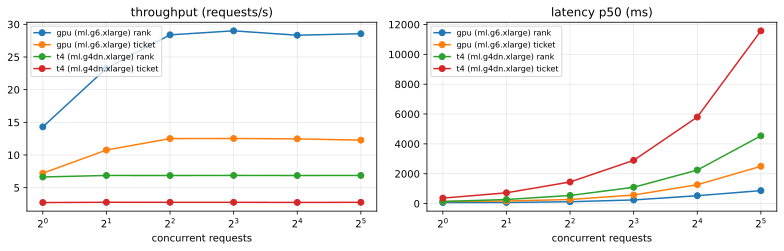

In [9]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ["svg"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for (k, kind), g in bench.groupby(["endpoint", "workload"]):
    label = f"{k} ({INSTANCE[k]}) {kind}"
    ax[0].plot(g.concurrency, g.req_per_s, "o-", label=label)
    ax[1].plot(g.concurrency, g.e2e_p50_ms, "o-", label=label)
for a, t in zip(ax, ("throughput (requests/s)", "latency p50 (ms)")):
    a.set_xscale("log", base=2); a.set_xlabel("concurrent requests"); a.set_title(t); a.grid(alpha=.3); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. More questions about the same state are nearly free
The engine encodes the state once and shares that work across all the questions asked about it (a shared-prefix
cache), so an agent can ask several questions in one request for little more than the cost of one.

In [10]:
STATE = ("Customer: I was charged twice for my annual plan, the second charge was on my old card that I removed "
         "last month, and I need a refund before my rent is due on Friday. ") * 4
QPOOL = [
    {"type": "noul", "instructions": "Is this urgent?"},
    {"type": "choice", "instructions": "Which team should handle this?", "criteria": DEPARTMENTS},
    {"type": "score", "instructions": "How frustrated is the customer?", "criteria": ["Calm", "Frustrated", "Very angry"]},
    {"type": "noul", "instructions": "Does the customer ask for a refund?"},
    {"type": "noul", "instructions": "Is a payment method mentioned?"},
]
per_state = []
for nq in (1, 5, 10, 20):
    body = {"state": STATE, "questions": {f"q{i}": QPOOL[i % len(QPOOL)] for i in range(nq)}}
    ms = np.median([invoke(names["gpu"], body)["latency_ms"] for _ in range(5)])
    per_state.append({"questions": nq, "server_ms": ms})
per_state = pd.DataFrame(per_state).assign(ms_per_question=lambda d: d.server_ms / d.questions)
per_state

,questions,server_ms,ms_per_question
0,1,63.5,63.5
1,5,135.4,27.1
2,10,207.3,20.7
3,20,384.1,19.2


## 10. Server-side metrics from Amazon CloudWatch
`ModelLatency` is the time spent in the container and `OverheadLatency` SageMaker's own share. GPU and CPU
utilisation show which resource limits throughput. Metrics arrive with a 1-2 minute delay; the cell waits for them.

In [11]:
cw = session.client("cloudwatch")
time.sleep(150)

def metric(k, name, namespace, stat="Maximum"):
    """Aggregate the 1-minute datapoints over the benchmark window: the request-weighted mean for Average, the
    total for Sum, the highest minute for Maximum."""
    dims = [{"Name": "EndpointName", "Value": names[k]}, {"Name": "VariantName", "Value": "AllTraffic"}]
    for d in (dims, dims + [{"Name": "InstanceType", "Value": INSTANCE[k]}]):   # pooled endpoints add InstanceType
        r = cw.get_metric_statistics(Namespace=namespace, MetricName=name, StartTime=window[k][0],
                                     EndTime=window[k][1], Period=60, Statistics=[stat, "SampleCount"], Dimensions=d)
        if points := r["Datapoints"]:
            if stat == "Average":
                return sum(p["Average"] * p["SampleCount"] for p in points) / sum(p["SampleCount"] for p in points)
            return sum(p["Sum"] for p in points) if stat == "Sum" else max(p[stat] for p in points)
    return float("nan")

server = pd.DataFrame({k: {
    "ModelLatency, average (ms)": metric(k, "ModelLatency", "AWS/SageMaker", "Average") / 1000,
    "OverheadLatency, average (ms)": metric(k, "OverheadLatency", "AWS/SageMaker", "Average") / 1000,
    "GPUUtilization, max (%)": metric(k, "GPUUtilization", "/aws/sagemaker/Endpoints"),
    "GPUMemoryUtilization, max (%)": metric(k, "GPUMemoryUtilization", "/aws/sagemaker/Endpoints"),
    "CPUUtilization, max (%, 100 per vCPU)": metric(k, "CPUUtilization", "/aws/sagemaker/Endpoints"),
    "MemoryUtilization, max (%)": metric(k, "MemoryUtilization", "/aws/sagemaker/Endpoints"),
    "Invocation5XXErrors, total": metric(k, "Invocation5XXErrors", "AWS/SageMaker", "Sum"),
} for k in names}).rename(columns=lambda k: f"{k} ({INSTANCE[k]})")
server.round(1)

,t4 (ml.g4dn.xlarge),gpu (ml.g6.xlarge)
"ModelLatency, average (ms)",2520.7,576.3
"OverheadLatency, average (ms)",4.1,3.8
"GPUUtilization, max (%)",97.0,100.0
"GPUMemoryUtilization, max (%)",64.7,55.2
"CPUUtilization, max (%, 100 per vCPU)",101.2,182.7
"MemoryUtilization, max (%)",12.7,63.8
"Invocation5XXErrors, total",0.0,0.0


## 11. Which instance is cheaper per request?
At each endpoint's best measured throughput, with one instance running all hour.

In [12]:
best = bench.loc[bench.groupby(["endpoint", "workload"]).req_per_s.idxmax()]
cost = best[["endpoint", "instance", "workload", "concurrency", "req_per_s", "e2e_p50_ms"]].assign(
    usd_per_hour=best.instance.map(PRICE_PER_HOUR),
    usd_per_million_requests=lambda d: d.usd_per_hour / (d.req_per_s * 3600) * 1e6)
summary = {"instances": INSTANCE, "quality": quality, "bench": bench.to_dict("records"),
           "per_state": per_state.to_dict("records"), "server": server.to_dict(), "cost": cost.to_dict("records")}
def finite(x):
    """JSON has no NaN: a metric CloudWatch did not report is written as null."""
    if isinstance(x, dict):
        return {k: finite(v) for k, v in x.items()}
    if isinstance(x, list):
        return [finite(v) for v in x]
    x = x.item() if hasattr(x, "item") else x                      # NumPy scalars
    return None if isinstance(x, float) and math.isnan(x) else x

Path("results.json").write_text(json.dumps(finite(summary), indent=1, allow_nan=False))
cost.round(2)

,endpoint,instance,workload,concurrency,req_per_s,e2e_p50_ms,usd_per_hour,usd_per_million_requests
21,gpu,ml.g6.xlarge,rank,8,29.0,242.8,1.1,10.8
15,gpu,ml.g6.xlarge,ticket,8,12.5,574.1,1.1,25.0
9,t4,ml.g4dn.xlarge,rank,8,6.9,1093.4,0.7,29.8
1,t4,ml.g4dn.xlarge,ticket,2,2.8,722.4,0.7,74.0


## 12. Production next steps (optional)
* **Autoscaling.** Track `SageMakerVariantInvocationsPerInstance` with the target taken from the measured peak with 30%
  headroom (next cell). Size it for your heaviest workload.
* **Scale to zero** for spiky or dev traffic: deploy the model as an *inference component* with `MinInstanceCount=0`.
* **Private networking:** add `VpcConfig` to `create_model` with an S3 gateway endpoint and ECR interface endpoints.
* **Your data.** States often hold customer text (names, account numbers, health or payment details). You are
  responsible for handling it under the laws and standards that apply to you (for example GDPR, HIPAA or PCI DSS):
  encrypt endpoint storage with your own KMS key (`KmsKeyId` on the endpoint config), keep CloudWatch log retention
  short, and do not turn on data capture for regulated data without the controls it needs. The server logs only
  errors, never request bodies.

In [13]:
TARGET = {f"{k}/{w}": round(v * 60 * 0.7) for (k, w), v in bench.groupby(["endpoint", "workload"]).req_per_s.max().items()}
print("autoscaling target (invocations per instance per minute):", TARGET)
# aas = session.client("application-autoscaling")
# rid = f"endpoint/{names['gpu']}/variant/AllTraffic"
# aas.register_scalable_target(ServiceNamespace="sagemaker", ResourceId=rid,
#                              ScalableDimension="sagemaker:variant:DesiredInstanceCount", MinCapacity=1, MaxCapacity=4)
# aas.put_scaling_policy(PolicyName=f"{names['gpu']}-ipi", ServiceNamespace="sagemaker", ResourceId=rid,
#                        ScalableDimension="sagemaker:variant:DesiredInstanceCount", PolicyType="TargetTrackingScaling",
#                        TargetTrackingScalingPolicyConfiguration={"TargetValue": float(TARGET["gpu/ticket"]),
#                            "PredefinedMetricSpecification": {"PredefinedMetricType": "SageMakerVariantInvocationsPerInstance"}})

autoscaling target (invocations per instance per minute): {'gpu/rank': 1218, 'gpu/ticket': 526, 't4/rank': 289, 't4/ticket': 116}


## 13. Clean up
Uncomment and run to delete both endpoints (this stops billing), their configs and models, their log groups, this
notebook's S3 artifact prefix, and the ECR repository and IAM role this notebook created. It only needs the configuration cell
(section 1), so it also works after a kernel restart, and it skips anything that is already gone.

In [14]:
# def gone(call, **kw):
#     try:
#         call(**kw)
#     except ClientError as e:
#         print("skipped:", e.response["Error"]["Code"], kw)
# def ours(describe, arn_key, **kw):
#     """True only for a resource that exists and carries this notebook's tag, so a same-named one is kept."""
#     try:
#         return ROLE_TAG in sm.list_tags(ResourceArn=describe(**kw)[arn_key])["Tags"]
#     except ClientError:
#         return False
# owned = {k: {"endpoint": ours(sm.describe_endpoint, "EndpointArn", EndpointName=f"{NAME}-{k}"),
#              "config": ours(sm.describe_endpoint_config, "EndpointConfigArn", EndpointConfigName=f"{NAME}-{k}"),
#              "model": ours(sm.describe_model, "ModelArn", ModelName=f"{NAME}-{k}")} for k in ENDPOINTS}
# for k in ENDPOINTS:
#     n = f"{NAME}-{k}"
#     if owned[k]["endpoint"]:                # with the autoscaling target, if section 12 attached one
#         gone(session.client("application-autoscaling").deregister_scalable_target, ServiceNamespace="sagemaker",
#              ResourceId=f"endpoint/{n}/variant/AllTraffic", ScalableDimension="sagemaker:variant:DesiredInstanceCount")
#         gone(sm.delete_endpoint, EndpointName=n)
# for k in ENDPOINTS:
#     n = f"{NAME}-{k}"
#     if owned[k]["endpoint"]:
#         sm.get_waiter("endpoint_deleted").wait(EndpointName=n)   # its last log lines must land before the log group goes
#         gone(session.client("logs").delete_log_group, logGroupName=f"/aws/sagemaker/Endpoints/{n}")
#     if owned[k]["config"]:
#         gone(sm.delete_endpoint_config, EndpointConfigName=n)
#     if owned[k]["model"]:
#         gone(sm.delete_model, ModelName=n)
#     kept = [r for r, mine in owned[k].items() if not mine]
#     if kept:
#         print(f"{n}: kept {kept} (missing, or not created by this notebook)")
# # Only this notebook's artifact prefix, every version included (on a versioned bucket, deleting only the current
# # objects would leave 4.7 GB billing).
# PREFIX = f"strands-decider/{DECIDER_REV[:8]}-{BASE_REV[:8]}/"
# for p in s3.get_paginator("list_object_versions").paginate(Bucket=BUCKET, Prefix=PREFIX, ExpectedBucketOwner=account):
#     objs = [{"Key": v["Key"], "VersionId": v["VersionId"]} for v in p.get("Versions", []) + p.get("DeleteMarkers", [])]
#     if objs:
#         r = s3.delete_objects(Bucket=BUCKET, ExpectedBucketOwner=account, Delete={"Objects": objs})
#         if r.get("Errors"):
#             raise RuntimeError(f"{len(r['Errors'])} S3 objects were not deleted: {r['Errors'][:3]}")
# try:
#     repo_arn = ecr.describe_repositories(repositoryNames=[REPO])["repositories"][0]["repositoryArn"]
#     if {"Key": "created-by", "Value": "strands-decider-sagemaker-sample"} in ecr.list_tags_for_resource(resourceArn=repo_arn)["tags"]:
#         ecr.delete_repository(repositoryName=REPO, force=True)        # only the repository this notebook created
# except ecr.exceptions.RepositoryNotFoundException:
#     pass
# iam = session.client("iam")
# try:
#     ours = ROLE_TAG in iam.list_role_tags(RoleName=ROLE_NAME)["Tags"]      # only the role this notebook created
# except iam.exceptions.NoSuchEntityException:
#     ours = False
# if ours:
#     gone(iam.delete_role_policy, RoleName=ROLE_NAME, PolicyName="strands-decider-endpoint")
#     gone(iam.delete_role_policy, RoleName=ROLE_NAME, PolicyName="strands-decider-kms")
#     gone(iam.delete_role, RoleName=ROLE_NAME)
# print("clean-up done")